In [ ]:
# ----------------- Librerías -----------------
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from imblearn.over_sampling import ADASYN
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from sklearn.manifold import TSNE

# ----------------- Configuración -----------------
RANDOM_STATE = 42
N_SPLITS =  5
MAX_EPOCHS = 100
EARLY_STOPPING = 100
N_ITER_RANDOM_SEARCH = 5
VERBOSE = 0

In [ ]:
# ----------------- Cargar datos -----------------
data = pd.read_csv("data/Cleaned.csv")
print("Dimensiones:", data.shape)
print("Columnas:", data.columns.tolist())
print(data["NoShow"].value_counts(normalize=True))

# ----------------- Preprocesamiento -----------------
target = "NoShow"
y = data[target]
X = data.drop(columns=[target])

# Identificar columnas categóricas
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_values = X_scaled
y_values = y.values

# ----------------- Hiperparámetros -----------------
param_grid = {
    "n_d": [8, 16, 32],
    "n_a": [8, 16, 32],
    "n_steps": [3, 5, 7],
    "gamma": [1.0, 1.5, 2.0],
    "lambda_sparse": [1e-4, 1e-3, 1e-2],
    "optimizer_params": [{"lr": lr} for lr in [1e-2, 1e-3]],
    "batch_size": [128, 256, 512],
    "virtual_batch_size": [32, 64, 128],
    "mask_type": ["entmax", "sparsemax"],
}

import random
random.seed(RANDOM_STATE)
all_params = []
for i in range(N_ITER_RANDOM_SEARCH):
    params = {k: random.choice(v) for k, v in param_grid.items()}
    all_params.append(params)

Dimensiones: (110526, 17)
Columnas: ['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'NoShow', 'ScheduledDay_DayOfWeek', 'AppointmentDay_DayOfWeek', 'DaysToAppointment', 'ScheduledDay_Year', 'ScheduledDay_Month', 'AppointmentDay_Year', 'AppointmentDay_Month']
NoShow
0    0.798066
1    0.201934
Name: proportion, dtype: float64


In [ ]:
# Crear carpeta de salida
os.makedirs("outputs/TABNET", exist_ok=True)

# ----------------- Validación cruzada -----------------
best_f1, best_params = -1, None
all_folds = []
summaries = []

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
for i, params in enumerate(all_params):
    fold_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "roc_auc": []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_values, y_values), 1):
        X_train, y_train = X_values[train_idx], y_values[train_idx]
        X_val, y_val = X_values[val_idx], y_values[val_idx]

        # Balanceo con ADASYN
        X_res, y_res = ADASYN(random_state=RANDOM_STATE).fit_resample(X_train, y_train)

        bs, vbs = params["batch_size"], params["virtual_batch_size"]
        if bs % vbs != 0:
            bs = (bs // vbs) * vbs
            if bs == 0: bs = vbs

        clf = TabNetClassifier(
            n_d=params["n_d"], n_a=params["n_a"], n_steps=params["n_steps"],
            gamma=params["gamma"], lambda_sparse=params["lambda_sparse"],
            mask_type=params["mask_type"],
            optimizer_fn=torch.optim.Adam,
            optimizer_params=params["optimizer_params"],
            verbose=VERBOSE,
            device_name="cuda" if torch.cuda.is_available() else "cpu"
        )

        clf.fit(
            X_res, y_res,
            eval_set=[(X_val, y_val)],
            max_epochs=MAX_EPOCHS, patience=EARLY_STOPPING,
            batch_size=bs, virtual_batch_size=vbs
        )

        y_pred = clf.predict(X_val)
        y_proba = clf.predict_proba(X_val)[:, 1]

        # Calcular métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        auc = roc_auc_score(y_val, y_proba)

        fold_metrics["accuracy"].append(acc)
        fold_metrics["precision"].append(prec)
        fold_metrics["recall"].append(rec)
        fold_metrics["f1"].append(f1)
        fold_metrics["roc_auc"].append(auc)

        # Guardar resultado de este fold
        all_folds.append({
            "iter": i+1,
            "fold": fold,
            **params,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "roc_auc": auc
        })

    # Calcular medias y std por iteración
    summary = {
        "iter": i+1,
        **params,
        "accuracy_mean": np.mean(fold_metrics["accuracy"]),
        "accuracy_std": np.std(fold_metrics["accuracy"]),
        "precision_mean": np.mean(fold_metrics["precision"]),
        "precision_std": np.std(fold_metrics["precision"]),
        "recall_mean": np.mean(fold_metrics["recall"]),
        "recall_std": np.std(fold_metrics["recall"]),
        "f1_mean": np.mean(fold_metrics["f1"]),
        "f1_std": np.std(fold_metrics["f1"]),
        "roc_auc_mean": np.mean(fold_metrics["roc_auc"]),
        "roc_auc_std": np.std(fold_metrics["roc_auc"]),
    }
    summaries.append(summary)

    avg_f1 = summary["f1_mean"]
    print(f"Iter {i+1}/{N_ITER_RANDOM_SEARCH}, F1 promedio: {avg_f1:.4f}")
    if avg_f1 > best_f1:
        best_f1, best_params = avg_f1, params




Stop training because you reached max_epochs = 100 with best_epoch = 24 and best_val_0_auc = 0.72259


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 100 with best_epoch = 75 and best_val_0_auc = 0.7203


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 100 with best_epoch = 19 and best_val_0_auc = 0.72006


...

Stop training because you reached max_epochs = 100 with best_epoch = 0 and best_val_0_auc = 0.69941


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 100 with best_epoch = 15 and best_val_0_auc = 0.71834


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Iter 5/5, F1 promedio: 0.4321


In [ ]:
# ----------------- Guardar resultados -----------------
df_folds = pd.DataFrame(all_folds)
df_summary = pd.DataFrame(summaries)

df_folds.to_csv("outputs/TABNET/fold_result.csv", index=False)
df_summary.to_csv("outputs/TABNET/summary_result.csv", index=False)

print("\nBest Params:", best_params)
print("Best F1:", best_f1)
print("Results saved in:")
print(" - outputs/TABNET/fold_result.csv")
print(" - outputs/TABNET/summary_result.csv")


Best Params: {'n_d': 32, 'n_a': 32, 'n_steps': 7, 'gamma': 1.0, 'lambda_sparse': 0.01, 'optimizer_params': {'lr': 0.001}, 'batch_size': 128, 'virtual_batch_size': 32, 'mask_type': 'entmax'}
Best F1: 0.43949064403261495
Results saved in:
 - TABNET/outputs/fold_results.csv
 - TABNET/outputs/summary_results.csv


In [ ]:
# ----------------- Entrenamiento final -----------------
bs, vbs = best_params["batch_size"], best_params["virtual_batch_size"]
if bs % vbs != 0:
    bs = (bs // vbs) * vbs
    if bs == 0: bs = vbs
    print(f"Ajustando batch_size a {bs} para que sea múltiplo de virtual_batch_size={vbs}")

X_res, y_res = ADASYN(random_state=RANDOM_STATE).fit_resample(X_values, y_values)

final_clf = TabNetClassifier(
    n_d=best_params["n_d"], n_a=best_params["n_a"], n_steps=best_params["n_steps"],
    gamma=best_params["gamma"], lambda_sparse=best_params["lambda_sparse"],
    mask_type=best_params["mask_type"],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=best_params["optimizer_params"],
    verbose=VERBOSE,
    device_name="cuda" if torch.cuda.is_available() else "cpu"
)

final_clf.fit(
    X_res, y_res,
    eval_set=[(X_values, y_values)],
    max_epochs=MAX_EPOCHS, patience=EARLY_STOPPING,
    batch_size=bs, virtual_batch_size=vbs
)

Stop training because you reached max_epochs = 100 with best_epoch = 10 and best_val_0_auc = 0.72653


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Clasification report:
               precision    recall  f1-score   support

           0       0.94      0.47      0.63     88207
           1       0.29      0.87      0.44     22319

    accuracy                           0.55    110526
   macro avg       0.62      0.67      0.53    110526
weighted avg       0.81      0.55      0.59    110526

ROC-AUC: 0.7265275253948265


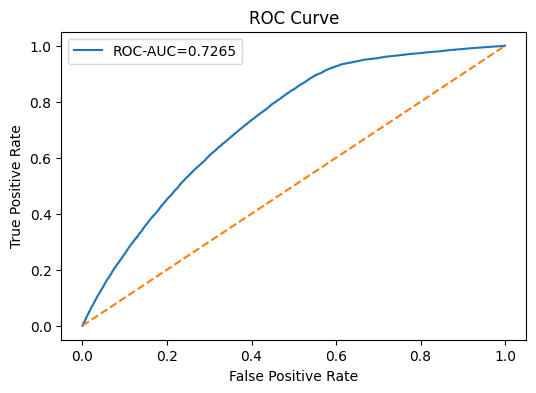

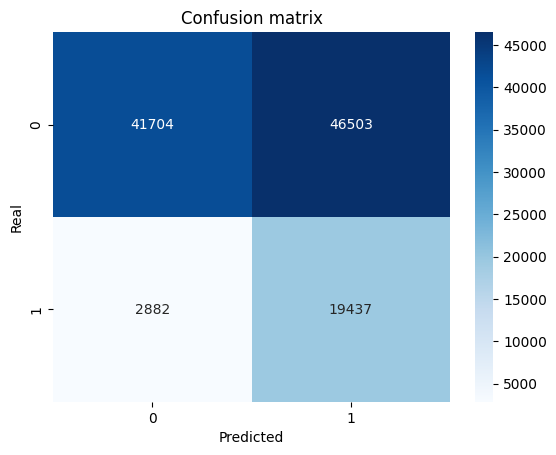

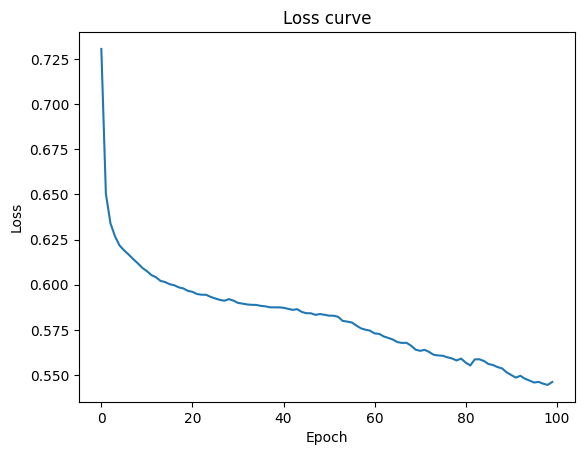

In [ ]:
# ----------------- Evaluación -----------------
y_pred = final_clf.predict(X_values)
y_proba = final_clf.predict_proba(X_values)[:, 1]

print("\nClasification report:\n", classification_report(y_values, y_pred))
print("ROC-AUC:", roc_auc_score(y_values, y_proba))

# Curva ROC
fpr, tpr, _ = roc_curve(y_values, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(y_values, y_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Matriz de confusión
cm = confusion_matrix(y_values, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

# Curva de pérdidas
losses = final_clf.history["loss"]
plt.plot(losses)
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


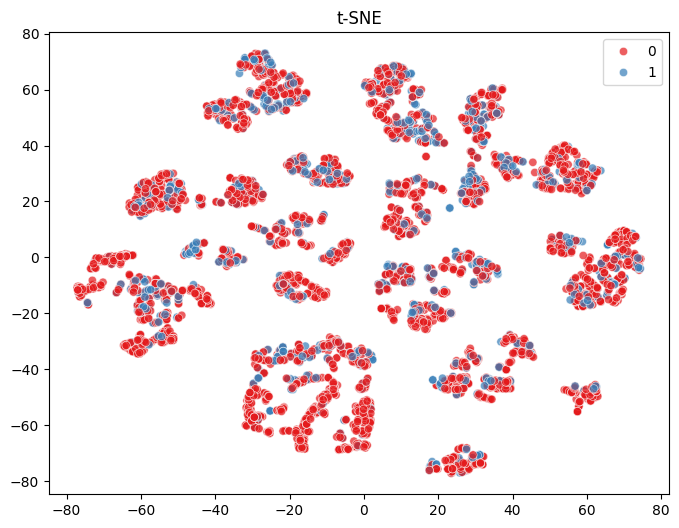

In [ ]:
# ----------------- Visualización con t-SNE -----------------
sample_size = min(5000, X_values.shape[0])
X_sample, y_sample = X_values[:sample_size], y_values[:sample_size]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000)
X_embedded = tsne.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_sample,
                palette="Set1", alpha=0.7)
plt.title("t-SNE")
plt.show()